In [35]:
import os
import random
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    Add, GlobalAveragePooling2D, Dropout, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU available: {[g.name for g in gpus]}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('⚠️  No GPU — enable in Settings → Accelerator')

print(f'TensorFlow: {tf.__version__}')

✅ GPU available: ['/physical_device:GPU:0', '/physical_device:GPU:1']
TensorFlow: 2.19.0


In [ ]:
# CORRECT PATHS
COMP_DIR    = '/kaggle/input/competitions/shift-guard-10-robust-image-classification-challenge'
TRAIN_DIR   = os.path.join(COMP_DIR, 'train_images')
TEST_DIR    = os.path.join(COMP_DIR, 'test_images')
LABELS_CSV  = os.path.join(COMP_DIR, 'train_labels.csv')
CLASSES_TXT = os.path.join(COMP_DIR, 'classes.txt')
SAMPLE_SUB  = os.path.join(COMP_DIR, 'sample_submission.csv')

# Read class names
with open(CLASSES_TXT, 'r') as f:
    CLASS_NAMES = [line.strip() for line in f.readlines() if line.strip()]
NUM_CLASSES = len(CLASS_NAMES)
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

#  Read CSv
train_df   = pd.read_csv(LABELS_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)
id_col     = train_df.columns[0]
label_col  = train_df.columns[1]

print(f'\nTrain CSV — {train_df.shape[0]} rows')
print(f'Columns: {list(train_df.columns)}')
print(train_df.head())

# See what filenames look like 
train_files = sorted(os.listdir(TRAIN_DIR))[:5]
test_files  = sorted(os.listdir(TEST_DIR))[:5]
print(f'\nTrain files sample: {train_files}')
print(f'Test files sample:  {test_files}')
print(f'Sample CSV ID: "{train_df[id_col].iloc[0]}"')

Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Train CSV — 29400 rows
Columns: ['id', 'label']
   id       label
0   1         cat
1   2         dog
2   3        deer
3   4  automobile
4   5        bird

Train files sample: ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']
Test files sample:  ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']
Sample CSV ID: "1"


In [ ]:
# Load training images (zero-pad IDs to match filenames)
def load_training_data(df, img_dir, label_map, id_col, label_col):
    images = []
    labels = []
    skipped = []

    for _, row in df.iterrows():
        img_id = int(row[id_col])
        label  = str(row[label_col]).strip()

        if label not in label_map:
            skipped.append(f'bad_label:{label}')
            continue

        # Zero-pad to 6 digits: 1 → "000001.png"
        filename = f'{img_id:06d}.png'
        filepath = os.path.join(img_dir, filename)

        if not os.path.exists(filepath):
            skipped.append(filename)
            continue

        img = Image.open(filepath).convert('RGB')
        images.append(np.array(img))
        labels.append(label_map[label])

    if skipped:
        print(f'⚠️  Skipped {len(skipped)}. First 5: {skipped[:5]}')
    else:
        print('✅ No files skipped')

    return np.array(images), np.array(labels)


def load_test_data(img_dir):
    images = []
    image_ids = []
    for fname in sorted(os.listdir(img_dir)):
        fpath = os.path.join(img_dir, fname)
        if not os.path.isfile(fpath):
            continue
        img = Image.open(fpath).convert('RGB')
        images.append(np.array(img))
        image_ids.append(os.path.splitext(fname)[0])
    return np.array(images), image_ids


print('Loading training images...')
X_train, Y_train = load_training_data(
    train_df, TRAIN_DIR, label_to_idx, id_col, label_col
)
print(f'✅ X_train: {X_train.shape}, Y_train: {Y_train.shape}')

print('\nLoading test images...')
X_test_raw, test_ids = load_test_data(TEST_DIR)
print(f'✅ X_test: {X_test_raw.shape}, Test IDs: {len(test_ids)}')

assert X_train.shape[0] > 0, 'No training images loaded!'
assert X_train.shape[0] == Y_train.shape[0], 'Misaligned!'
print(f'\nImage size: {X_train.shape[1]}x{X_train.shape[2]}x{X_train.shape[3]}')
print(f'Pixel range: [{X_train.min()}, {X_train.max()}]')
print(f'✅ {X_train.shape[0]} training images + {X_test_raw.shape[0]} test images loaded')

Loading training images...
✅ No files skipped
✅ X_train: (29400, 32, 32, 3), Y_train: (29400,)

Loading test images...
✅ X_test: (7600, 32, 32, 3), Test IDs: 7600

Image size: 32x32x3
Pixel range: [0, 255]
✅ 29400 training images + 7600 test images loaded


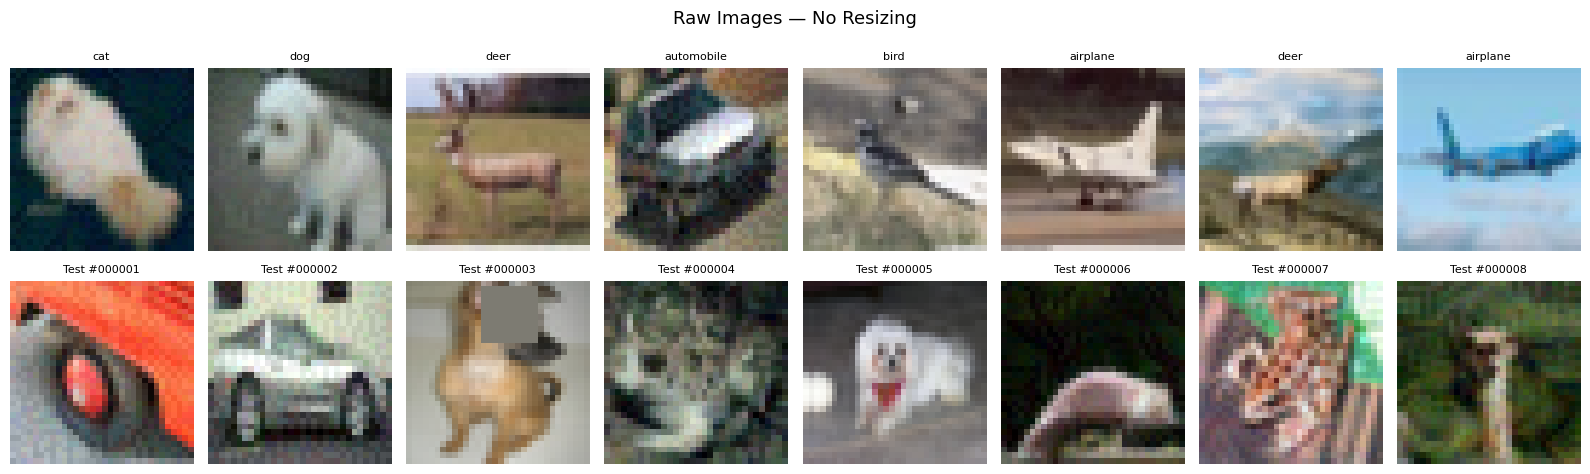

In [38]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(CLASS_NAMES[Y_train[i]], fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(X_test_raw[i])
    axes[1, i].set_title(f'Test #{test_ids[i]}', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Train', fontsize=10)
axes[1, 0].set_ylabel('Test', fontsize=10)
plt.suptitle('Raw Images — No Resizing', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = X_train.shape[1]
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')

# Normalise
X_train_f = X_train.astype('float32') / 255.0
X_test_f  = X_test_raw.astype('float32') / 255.0

# Compute mean/std from training data (no external data)
CHANNEL_MEAN = X_train_f.mean(axis=(0, 1, 2))
CHANNEL_STD  = X_train_f.std(axis=(0, 1, 2))
print(f'Mean: {CHANNEL_MEAN}')
print(f'Std:  {CHANNEL_STD}')

X_train_norm = (X_train_f - CHANNEL_MEAN) / CHANNEL_STD
X_test_norm  = (X_test_f  - CHANNEL_MEAN) / CHANNEL_STD

# One-hot encode 
Y_train_ohe = tf.keras.utils.to_categorical(Y_train, NUM_CLASSES)

# 80/20 stratified split
X_tr, X_val, Y_tr, Y_val, Y_tr_int, Y_val_int = train_test_split(
    X_train_norm, Y_train_ohe, Y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=Y_train
)

print(f'\nTraining   : {X_tr.shape[0]}')
print(f'Validation : {X_val.shape[0]}')
print(f'Test       : {X_test_norm.shape[0]}')
print('✅ Preprocessing done')

Image size: 32x32
Mean: [0.48568204 0.4736163  0.42534426]
Std:  [0.23912902 0.23467314 0.25398216]

Training   : 23520
Validation : 5880
Test       : 7600
✅ Preprocessing done


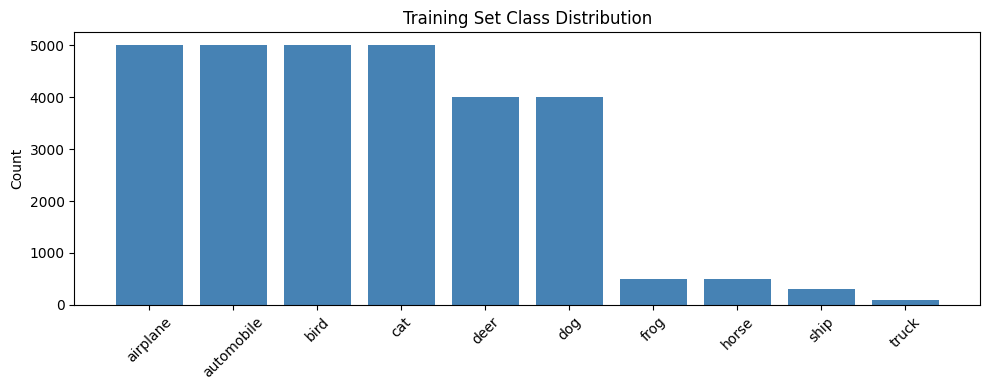

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
unique, counts = np.unique(Y_train, return_counts=True)
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
ax.set_title('Training Set Class Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

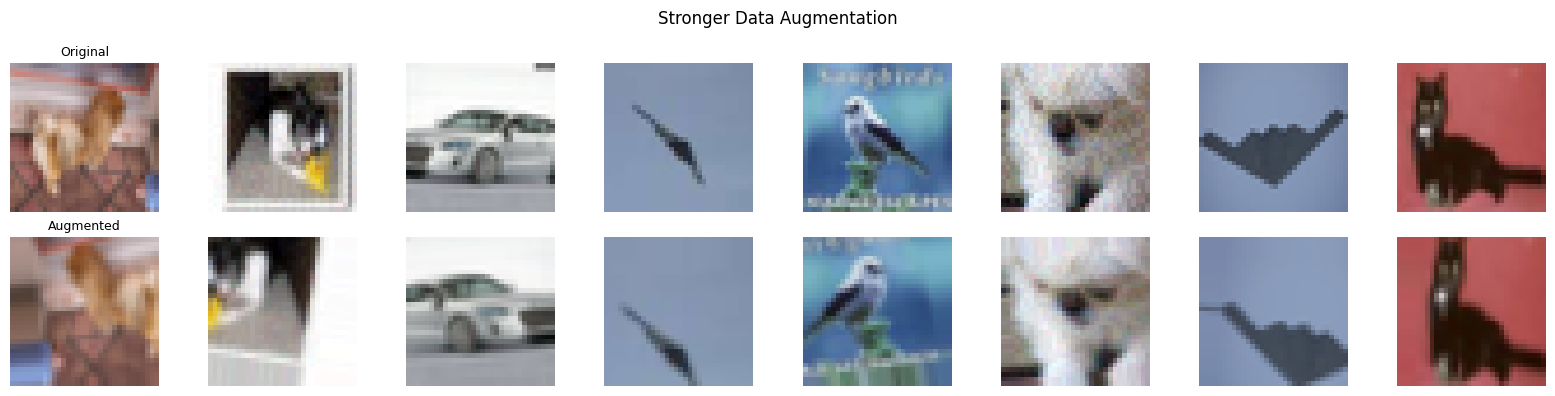

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Much stronger augmentation to handle shifted/corrupted images 
datagen = ImageDataGenerator(
    width_shift_range=0.2,        # was 0.125
    height_shift_range=0.2,       # was 0.125
    horizontal_flip=True,
    rotation_range=20,            # was 15
    zoom_range=0.15,              # was 0.1
    shear_range=0.1,              # NEW
    channel_shift_range=0.1,      # NEW — helps with color shifts
    fill_mode='nearest'
)
datagen.fit(X_tr)

# Visualise
sample_imgs = X_tr[:8]
aug_batch   = next(datagen.flow(sample_imgs, batch_size=8, shuffle=False))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    orig = np.clip(sample_imgs[i] * CHANNEL_STD + CHANNEL_MEAN, 0, 1)
    aug  = np.clip(aug_batch[i]   * CHANNEL_STD + CHANNEL_MEAN, 0, 1)
    axes[0, i].imshow(orig); axes[0, i].axis('off')
    axes[1, i].imshow(aug);  axes[1, i].axis('off')
axes[0, 0].set_title('Original', fontsize=9)
axes[1, 0].set_title('Augmented', fontsize=9)
plt.suptitle('Stronger Data Augmentation', fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
from tensorflow.keras.regularizers import l2

WEIGHT_DECAY = 1e-4

def residual_block(x, filters, strides=1, downsample=False):
    shortcut = x

    x = Conv2D(filters, 3, strides=strides, padding='same',
               kernel_initializer='he_normal', use_bias=False,
               kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, strides=1, padding='same',
               kernel_initializer='he_normal', use_bias=False,
               kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)

    if downsample:
        shortcut = Conv2D(filters, 1, strides=strides, padding='same',
                          kernel_initializer='he_normal', use_bias=False,
                          kernel_regularizer=l2(WEIGHT_DECAY))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def build_resnet_v2(input_shape, num_classes=10):
    inputs = Input(shape=input_shape)

    # Initial conv
    x = Conv2D(64, 3, strides=1, padding='same',
               kernel_initializer='he_normal', use_bias=False,
               kernel_regularizer=l2(WEIGHT_DECAY))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Group 1 — 64 filters (3 blocks instead of 2)
    x = residual_block(x, 64,  strides=1, downsample=False)
    x = residual_block(x, 64,  strides=1, downsample=False)
    x = residual_block(x, 64,  strides=1, downsample=False)

    # Group 2 — 128 filters
    x = residual_block(x, 128, strides=2, downsample=True)
    x = residual_block(x, 128, strides=1, downsample=False)
    x = residual_block(x, 128, strides=1, downsample=False)

    # Group 3 — 256 filters
    x = residual_block(x, 256, strides=2, downsample=True)
    x = residual_block(x, 256, strides=1, downsample=False)
    x = residual_block(x, 256, strides=1, downsample=False)

    # Group 4 — 512 filters
    x = residual_block(x, 512, strides=2, downsample=True)
    x = residual_block(x, 512, strides=1, downsample=False)
    x = residual_block(x, 512, strides=1, downsample=False)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu',
              kernel_initializer='he_normal',
              kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax',
                    kernel_initializer='he_normal')(x)

    return Model(inputs, outputs, name='ResNet_ShiftGuard10_v2')


INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
model = build_resnet_v2(INPUT_SHAPE, NUM_CLASSES)
model.summary()

total_params = model.count_params()
print(f'\nTotal parameters: {total_params:,}')

Model: "ResNet_ShiftGuard10_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_68 (Conv2D)  │ (None, 32, 32,    │      1,728 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_68[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_59       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_59[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_69[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_60       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_60[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_70[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_59[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_61       │ (None, 32, 32,    │          0 │ add_28[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_61[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_71[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_62       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_62[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_72[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 17,586,890 (67.09 MB)

 Trainable params: 17,573,450 (67.04 MB)

 Non-trainable params: 13,440 (52.50 KB)


Total parameters: 17,586,890


In [ ]:
BATCH_SIZE = 64          # smaller batch = better generalization
EPOCHS     = 300         # more epochs (early stopping will handle it)
CHECKPOINT = '/kaggle/working/best_model.keras'

# Cosine decay learning rate schedule
steps_per_epoch = max(1, len(X_tr) // BATCH_SIZE)
total_steps = steps_per_epoch * EPOCHS

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.005,
    decay_steps=total_steps,
    alpha=1e-6    # minimum learning rate
)

optimizer = SGD(learning_rate=lr_schedule, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks 
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=30,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        CHECKPOINT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

print(f'Training: {len(X_tr)} | Validation: {len(X_val)}')
print(f'Batch: {BATCH_SIZE} | Steps/epoch: {steps_per_epoch} | Max epochs: {EPOCHS}')
print(f'Initial LR: 0.005 with cosine decay\n')

history = model.fit(
    datagen.flow(X_tr, Y_tr, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

Training: 23520 | Validation: 5880
Batch: 64 | Steps/epoch: 367 | Max epochs: 300
Initial LR: 0.005 with cosine decay

Epoch 1/300
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3089 - loss: 3.4153

2026-04-05 20:27:11.614815: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_accuracy improved from -inf to 0.42160, saving model to /kaggle/working/best_model.keras
367/367 ━━━━━━━━━━━━━━━━━━━━ 76s 181ms/step - accuracy: 0.3091 - loss: 3.4144 - val_accuracy: 0.4216 - val_loss: 2.8854
Epoch 2/300
  1/367 ━━━━━━━━━━━━━━━━━━━━ 58s 160ms/step - accuracy: 0.3906 - loss: 2.9597
Epoch 2: val_accuracy did not improve from 0.42160
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3906 - loss: 2.9597 - val_accuracy: 0.4202 - val_loss: 2.9088
Epoch 3/300
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4496 - loss: 2.8450
Epoch 3: val_accuracy improved from 0.42160 to 0.50357, saving model to /kaggle/working/best_model.keras
367/367 ━━━━━━━━━━━━━━━━━━━━ 64s 174ms/step - accuracy: 0.4496 - loss: 2.8449 - val_accuracy: 0.5036 - val_loss: 2.6835
Epoch 4/300
  1/367 ━━━━━━━━━━━━━━━━━━━━ 58s 161ms/step - accuracy: 0.4844 - loss: 2.7679
Epoch 4: val_accuracy did not improve from 0.50357
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4844 - 

In [ ]:
if os.path.exists(CHECKPOINT):
    model.load_weights(CHECKPOINT)
    print('✅ Loaded best weights')

# Test-Time Augmentation (TTA)
# Instead of predicting once, predict multiple times with augmentation
# and average the predictions — this significantly boosts F1

def predict_with_tta(model, X, n_augments=20, batch_size=256):
    """Predict with test-time augmentation."""
    tta_datagen = ImageDataGenerator(
        width_shift_range=0.15,
        height_shift_range=0.15,
        horizontal_flip=True,
        rotation_range=15,
        zoom_range=0.1,
        fill_mode='reflect'
    )

    # Original prediction (no augmentation)
    predictions = model.predict(X, batch_size=batch_size, verbose=0)

    # Add augmented predictions
    for i in range(n_augments):
        aug_data = np.zeros_like(X)
        for j in range(0, len(X), batch_size):
            batch = X[j:j+batch_size]
            aug_batch = next(tta_datagen.flow(batch, batch_size=len(batch), shuffle=False))
            aug_data[j:j+len(batch)] = aug_batch

        aug_pred = model.predict(aug_data, batch_size=batch_size, verbose=0)
        predictions += aug_pred

        if (i + 1) % 5 == 0:
            print(f'  TTA round {i+1}/{n_augments} done')

    # Average all predictions
    predictions /= (n_augments + 1)
    return predictions


# Validation F1 without TTA 
val_pred_simple = np.argmax(model.predict(X_val, batch_size=256, verbose=0), axis=1)
f1_simple = f1_score(Y_val_int, val_pred_simple, average='macro')
print(f'\n🎯 Validation F1 (no TTA):   {f1_simple:.4f}')

# Validation F1 with TTA
print('\nRunning TTA on validation set...')
val_pred_tta_prob = predict_with_tta(model, X_val, n_augments=20)
val_pred_tta = np.argmax(val_pred_tta_prob, axis=1)
f1_tta = f1_score(Y_val_int, val_pred_tta, average='macro')
print(f'🎯 Validation F1 (with TTA): {f1_tta:.4f}')
print(f'📈 TTA improvement: +{f1_tta - f1_simple:.4f}')

if f1_tta >= 0.90:
    print('✅ F1 ≥ 0.90!')
else:
    print(f'⚠️  Gap to 0.90: {0.90 - f1_tta:.4f}')

print('\nClassification Report (with TTA):')
print(classification_report(Y_val_int, val_pred_tta, target_names=CLASS_NAMES))

✅ Loaded best weights


2026-04-05 23:18:44.691118: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



🎯 Validation F1 (no TTA):   0.7690

Running TTA on validation set...


2026-04-05 23:18:52.493590: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:18:57.875657: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 5/20 done


...

  TTA round 10/20 done


2026-04-05 23:19:45.944451: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:19:51.314438: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 15/20 done


2026-04-05 23:20:12.778178: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:20:18.095610: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 20/20 done
🎯 Validation F1 (with TTA): 0.7899
📈 TTA improvement: +0.0210
⚠️  Gap to 0.90: 0.1101

Classification Report (with TTA):
              precision    recall  f1-score   support

    airplane       0.92      0.93      0.93      1000
  automobile       0.96      0.98      0.97      1000
        bird       0.90      0.85      0.87      1000
         cat       0.82      0.84      0.83      1000
        deer       0.81      0.94      0.87       800
         dog       0.85      0.81      0.83       800
        frog       0.87      0.55      0.67       100
       horse       0.95      0.56      0.70       100
        ship       0.91      0.67      0.77        60
       truck       0.50      0.40      0.44        20

    accuracy                           0.88      5880
   macro avg       0.85      0.75      0.79      5880
weighted avg       0.88      0.88      0.88      5880



In [ ]:
# Predict test set WITH TTA 
print('Running TTA on test set (this takes a few minutes)...')
test_pred_prob   = predict_with_tta(model, X_test_norm, n_augments=20)
test_pred_idx    = np.argmax(test_pred_prob, axis=1)
test_pred_labels = [CLASS_NAMES[i] for i in test_pred_idx]

submission = pd.DataFrame({
    sample_sub.columns[0]: test_ids,
    sample_sub.columns[1]: test_pred_labels
})
submission.to_csv("submission22.csv", index=False)
print(f'Shape: {submission.shape}')
print(submission.head(10))

assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
print('✅ Ready to submit!')

Running TTA on test set (this takes a few minutes)...


2026-04-05 23:20:57.600310: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:21:04.487256: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 5/20 done


2026-04-05 23:21:39.116087: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:21:46.010484: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 10/20 done


2026-04-05 23:22:13.477260: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:22:20.358512: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 15/20 done


2026-04-05 23:22:47.725410: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-05 23:22:54.584865: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  TTA round 20/20 done
Shape: (7600, 2)
       id       label
0  000001  automobile
1  000002  automobile
2  000003         dog
3  000004        frog
4  000005         dog
5  000006        bird
6  000007        frog
7  000008        bird
8  000009        bird
9  000010        bird
✅ Ready to submit!


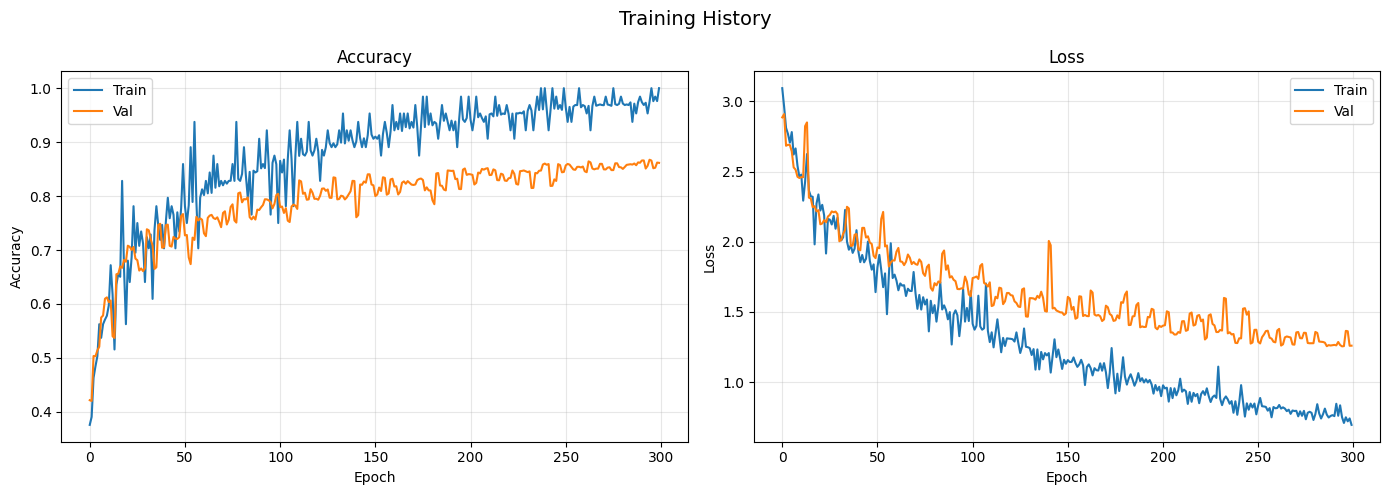

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-Class F1 Scores Bar Chart ─────────────────────────────────────────────
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Per-class F1
per_class_f1 = f1_score(Y_val_int, val_pred_tta, average=None)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart of per-class F1
colors = ['green' if f >= 0.90 else 'orange' if f >= 0.70 else 'red' for f in per_class_f1]
bars = axes[0].bar(CLASS_NAMES, per_class_f1, color=colors)
axes[0].axhline(y=0.90, color='green', linestyle='--', alpha=0.5, label='Target (0.90)')
axes[0].axhline(y=f1_tta, color='blue', linestyle='--', alpha=0.5, label=f'Macro F1 ({f1_tta:.3f})')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Per-Class F1 Score (green ≥0.90, orange ≥0.70, red <0.70)')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add F1 value on top of each bar
for bar, f in zip(bars, per_class_f1):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{f:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Confusion matrix heatmap
cm = confusion_matrix(Y_val_int, val_pred_tta)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title(f'Confusion Matrix (Macro F1 = {f1_tta:.4f})')

plt.tight_layout()
plt.show()

# ── Normalized confusion matrix (percentages) ────────────────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (% of each true class)')
plt.tight_layout()
plt.show()

# ── Print summary table ───────────────────────────────────────────────────────
print(f'\n{"Class":>12s}  {"Samples":>7s}  {"F1":>6s}  {"Status"}')
print('─' * 42)
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(Y_val_int == i)
    f = per_class_f1[i]
    status = '✅' if f >= 0.90 else '⚠️' if f >= 0.70 else '❌'
    print(f'{name:>12s}  {count:7d}  {f:.4f}  {status}')
print('─' * 42)
print(f'{"MACRO F1":>12s}  {"":>7s}  {f1_tta:.4f}')

In [ ]:
from IPython.display import FileLink
FileLink("submission22.csv")


/kaggle/working/submission22.csv